# Support Vector Machines 

Welcome to your SVM assignment! Just follow along with the notebook and instructions below. We will be analyzing the famous iris data set!

## The Data
For this series of lectures, we will be using the famous [Iris flower data set](http://en.wikipedia.org/wiki/Iris_flower_data_set). 

The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by Sir Ronald Fisher in the 1936 as an example of discriminant analysis. 

The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor), so 150 total samples. Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

Here's a picture of the three different Iris types:

In [50]:
# # The Iris Setosa
from IPython.display import Image, display
url = 'http://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg'
display(Image(url=url, width=300, height=300))

In [51]:
# The Iris Versicolor
url = 'http://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg'
display(Image(url=url, width=300, height=300))

In [52]:
# The Iris Virginica
url = 'http://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
display(Image(url=url, width=300, height=300))

The iris dataset contains measurements for 150 iris flowers from three different species.

The three classes in the Iris dataset:

    Iris-setosa (n=50)
    Iris-versicolor (n=50)
    Iris-virginica (n=50)

The four features of the Iris dataset:

    sepal length in cm
    sepal width in cm
    petal length in cm
    petal width in cm

## Get the data

**Use seaborn to get the iris data by using: iris = sns.load_dataset('iris') **

In [53]:
import seaborn as sns           
iris = sns.load_dataset('iris') # load the iris dataset

Let's visualize the data and get you started!

## Exploratory Data Analysis

Time to put your data viz skills to the test! Try to recreate the following plots, make sure to import the libraries you'll need!

**Import some libraries you think you'll need.**

In [54]:
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")

** Create a pairplot of the data set. Which flower species seems to be the most separable?**

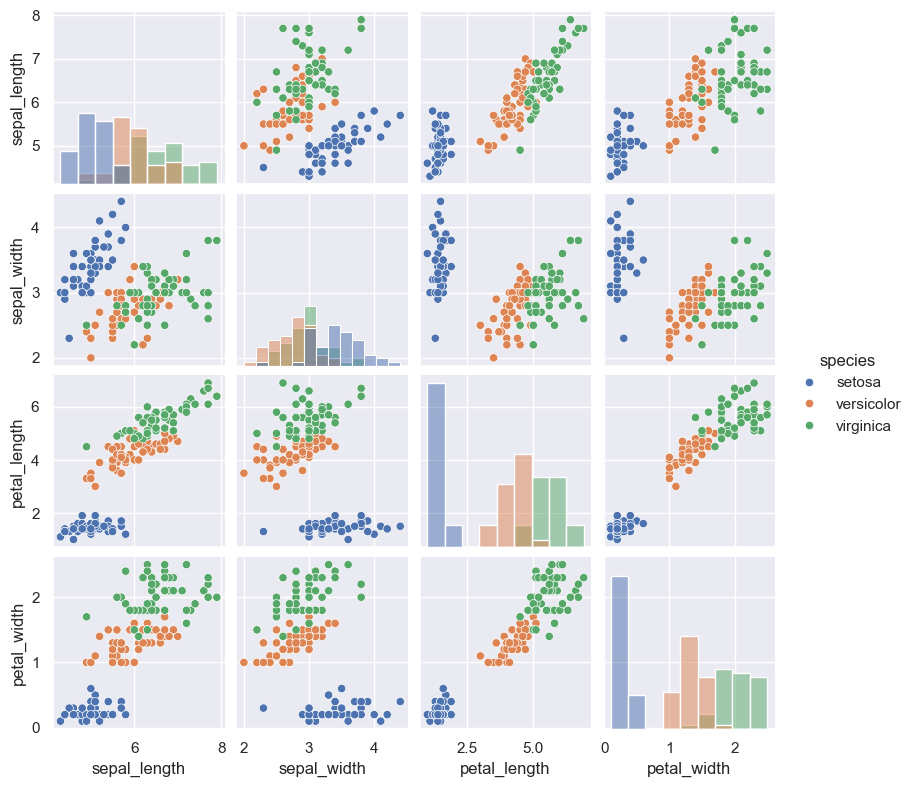

In [55]:
sns.pairplot(iris, hue='species', diag_kind='hist', height=2) # pairplot colored by species
plt.show()                        

**Create a kde plot of sepal_length versus sepal width for setosa species of flower.**

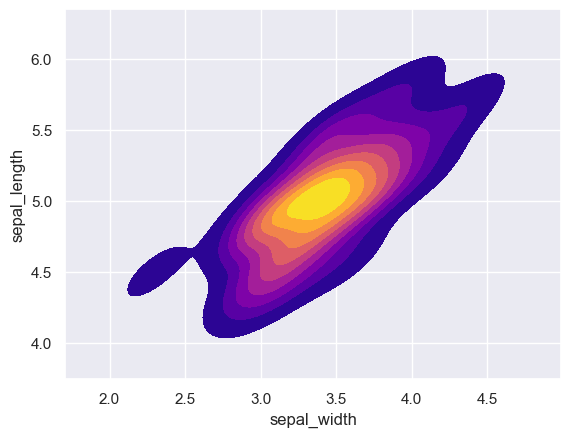

In [56]:
setosa = iris[iris['species'] == 'setosa'] # filter only setosa species

sns.kdeplot(data=setosa, x='sepal_width', y='sepal_length', fill=True, cmap='plasma')
plt.show()                       

# Train Test Split

** Split your data into a training set and a testing set.**

In [57]:
from sklearn.model_selection import train_test_split 

In [ ]:
X = iris.drop('species', axis=1) # features
y = iris['species']              # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

# Train a Model

Now its time to train a Support Vector Machine Classifier. 

**Call the SVC() model from sklearn and fit the model to the training data.**

In [59]:
from sklearn.svm import SVC # import SVM classifier

In [60]:
model = SVC() # SVM model

In [61]:
model.fit(X_train, y_train) # train the model

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Model Evaluation

**Now get predictions from the model and create a confusion matrix and a classification report.**

In [ ]:
predictions = model.predict(X_test) # predict

In [63]:
from sklearn.metrics import confusion_matrix, classification_report 

In [64]:
print(confusion_matrix(y_test,predictions))

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Wow! You should have noticed that your model was pretty good! Let's see if we can tune the parameters to try to get even better (unlikely, and you probably would be satisfied with these results in real like because the data set is quite small, but I just want you to practice using GridSearch.

## Gridsearch Practice

** Import GridsearchCV from SciKit Learn.**

In [66]:
from sklearn.model_selection import GridSearchCV # import GridSearchCV

**Create a dictionary called param_grid and fill out some parameters for C and gamma.**

In [ ]:
param_grid = {
    'C': [0.1, 1],        # different C values
    'gamma': [0.1, 0.01], # different gamma values
    'kernel': ['rbf']
}

** Create a GridSearchCV object and fit it to the training data.**

In [69]:
grid = GridSearchCV(SVC(), param_grid, verbose=3, cv=2)

** Now take that grid model and create some predictions using the test set and create classification reports and confusion matrices for them. Were you able to improve?**

In [70]:
grid.fit(X_train, y_train) # train GridSearchCV

Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV 1/2] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.717 total time=   0.0s
[CV 2/2] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.712 total time=   0.0s
[CV 1/2] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.358 total time=   0.0s
[CV 2/2] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.712 total time=   0.0s
[CV 1/2] END ........C=1, gamma=0.1, kernel=rbf;, score=0.962 total time=   0.0s
[CV 2/2] END ........C=1, gamma=0.1, kernel=rbf;, score=0.981 total time=   0.0s
[CV 1/2] END .......C=1, gamma=0.01, kernel=rbf;, score=0.792 total time=   0.0s
[CV 2/2] END .......C=1, gamma=0.01, kernel=rbf;, score=0.788 total time=   0.0s


,estimator,SVC()
,param_grid,"{'C': [0.1, 1], 'gamma': [0.1, 0.01], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,2
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [71]:
grid_predictions = grid.predict(X_test) # predict 

In [ ]:
print(confusion_matrix(y_test, grid_predictions)) 

[[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]


In [ ]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



The model did not improve significantly after using GridSearchCV. The accuracy and classification results remained almost the same because the original SVM model was already performing very well on the Iris dataset. 